# Задание для продуктового аналитика на стажировку Т-Банк Осень 2026

## Описание задачи

Команда запустила A/B тест новой формы оплаты ЖКХ с упрощённым заполнением реквизитов.

**Воронка оплаты ЖКХ**

1. Открыл форму оплаты → 2. Ввёл реквизиты → 3. Подтвердил платеж → 4. Успешная оплата.

**Ключевая метрика:** Конверсия из шага 1 в шаг 4 (успешная оплата).

**Гипотеза:** Новая форма с автозаполнением реквизитов увеличит долю успешных оплат ЖКХ.

**Длительность теста:** 30 дней (1–30 апреля 2024)

**Ваша задача:** Проанализировать результаты A/B теста и дать рекомендацию: запускать новую форму на всех пользователей или нет.

**Что нужно сделать:** Провести анализ данных A/B теста и подготовить рекомендацию для продуктовой команды. Данные сплитовались по клиентам, а так же в данных могут встречаться некорректные записи (например, пустые пользователи, аномальные значения) обработайте их соответствующим образом.

## Решение

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

### 1. Обработка данных

In [2]:
dfs = pd.read_excel('product_case.xlsx', sheet_name=[0, 1])
users = dfs[0]
conversion = dfs[1]
print('Размер таблицы пользователей:', users.shape)
print('Размер таблицы конверсии:', conversion.shape)

Размер таблицы пользователей: (1504, 5)
Размер таблицы конверсии: (2661, 7)


In [3]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1504 entries, 0 to 1503
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      1504 non-null   int64 
 1   group        1503 non-null   object
 2   age          1504 non-null   int64 
 3   city         1503 non-null   object
 4   device_type  1504 non-null   object
dtypes: int64(2), object(3)
memory usage: 58.9+ KB


Убираем дубликаты и строки таблицы пользователей, содержащие нулевые значения.

Считаем, что возвраст человека в пределах от 0 до 120. В противном случае удаляем.

In [4]:
users = users.drop_duplicates()
users = users.dropna()
users = users[(users['age'] > 0) & (users['age'] <= 120)]
users.shape

(1500, 5)

Визуализируем распределение пользователей групп 'A' и 'B' по возрасту, городам и типам устройств.

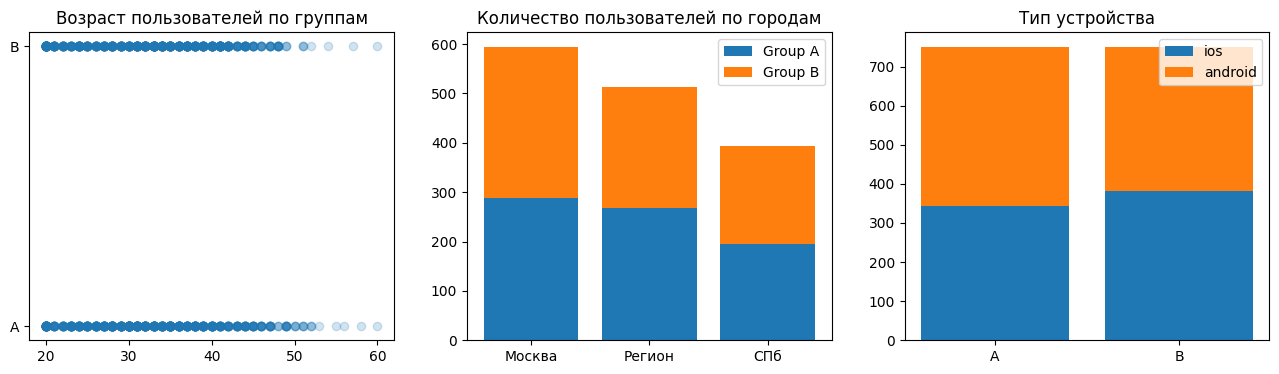

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
axs[0].scatter(users['age'], users['group'], marker='o', alpha=0.2)
axs[0].set_title('Возраст пользователей по группам')

cities = users['city'].unique()
usersA = users[users['group'] == 'A']
usersB = users[users['group'] == 'B']
users_in_cityA = [usersA[usersA['city'] == c].shape[0] for c in cities]
users_in_cityB = [usersB[usersB['city'] == c].shape[0] for c in cities]
axs[1].bar(cities, users_in_cityA, label='Group A')
axs[1].bar(cities, users_in_cityB, bottom=users_in_cityA, label='Group B')
axs[1].set_title('Количество пользователей по городам')
axs[1].legend()

devices = users['device_type'].unique()
users_with_deviceA = [usersA[usersA['device_type'] == d].shape[0] for d in devices]
users_with_deviceB = [usersB[usersB['device_type'] == d].shape[0] for d in devices]
prev_dev = None
for d in range(len(devices)):
  if prev_dev is None:
    axs[2].bar(users['group'].unique(), [users_with_deviceA[d], users_with_deviceB[d]], label=devices[d])
    prev_dev = [users_with_deviceA[d], users_with_deviceB[d]]
  else:
    axs[2].bar(users['group'].unique(), [users_with_deviceA[d], users_with_deviceB[d]], bottom=prev_dev, label=devices[d])
    prev_dev[0] += users_with_deviceA[d]
    prev_dev[1] += users_with_deviceB[d]
axs[2].set_title('Тип устройства')
axs[2].legend()

plt.show()

Заметим, что по всем признакам пользователи распределены по двум группам примерно равномерно.

Возраст попадает в рамки [20, 60], но в основном располагается между 20 и 45 лет.

Преимущественно пользователи находятся в Москве.

In [6]:
conversion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2661 entries, 0 to 2660
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   payment_id       2661 non-null   int64         
 1   user_id          2660 non-null   float64       
 2   group            2661 non-null   object        
 3   step1_opened     2661 non-null   datetime64[ns]
 4   step2_entered    2256 non-null   datetime64[ns]
 5   step3_confirmed  1719 non-null   datetime64[ns]
 6   step4_success    1522 non-null   datetime64[ns]
dtypes: datetime64[ns](4), float64(1), int64(1), object(1)
memory usage: 145.7+ KB


Фильтруем таблицу платежей. Удаляем платежи без user_id. Принимаем только платежи, все этапы которых проходили в заданном временном промежутке (апрель 2024).

In [7]:
conversion = conversion.drop_duplicates()
conversion = conversion.drop(columns=['group'])
conversion = conversion.dropna(subset=['user_id'])
conversion['user_id'] = conversion['user_id'].astype(int)
for date_col in ['step1_opened', 'step2_entered', 'step3_confirmed', 'step4_success']:
  conversion = conversion[conversion[date_col].isna() | (conversion[date_col].between('2024-04-01', '2024-04-30'))]
conversion.shape

(2576, 6)

Склеиваем таблицы в одну.

In [8]:
df = pd.merge(conversion, users, on='user_id', how='left')
df = df.dropna(subset=['user_id'])
print(df.shape)
df.head(5)

(2576, 10)


,payment_id,user_id,step1_opened,step2_entered,step3_confirmed,step4_success,group,age,city,device_type
0,5001,1001,2024-04-16 06:06:00,2024-04-16 06:10:00,NaT,NaT,A,31.0,Москва,ios
1,5002,1002,2024-04-12 07:38:00,2024-04-12 07:41:00,NaT,NaT,A,31.0,Москва,ios
2,5003,1003,2024-04-26 20:03:00,2024-04-26 20:07:00,NaT,NaT,A,25.0,Москва,android
3,5004,1004,2024-04-09 16:02:00,NaT,NaT,NaT,A,20.0,Москва,ios
4,5005,1004,2024-04-04 03:46:00,2024-04-04 03:54:00,2024-04-04 03:57:00,2024-04-04 04:02:00,A,20.0,Москва,ios


In [9]:
dfA = df[df['group'] == 'A']
dfB = df[df['group'] == 'B']
Apercent = 100 * dfA.shape[0] / (dfA.shape[0] + dfB.shape[0])
print(f'Размеры групп: \n A: {dfA.shape[0]}\n B: {dfB.shape[0]}\nРазбиение {Apercent:.1f}/{100 - Apercent:.1f} %')

Размеры групп: 
 A: 1267
 B: 1308
Разбиение 49.2/50.8 %


Проверяем соотношение числа пользователей в группах 'A' и 'B'. Оно близко к равному, переходим к следующему этапу.

### 2. Визуализация

In [39]:
step_cols = ['step1_opened', 'step2_entered', 'step3_confirmed', 'step4_success']
funnelA = []
funnelB = []
for c in step_cols:
  funnelA.append(dfA[~dfA[c].isna()].shape[0])
  funnelB.append(dfB[~dfB[c].isna()].shape[0])
results = pd.DataFrame([funnelA, funnelB])
results.columns = ['Открыл форму', 'Ввел реквизиты', 'Подтвердил платеж', 'Успешная оплата']
results.index = ['A', 'B']
results

,Открыл форму,Ввел реквизиты,Подтвердил платеж,Успешная оплата
A,1267,1027,734,628
B,1308,1156,932,845


In [45]:
conversions = pd.DataFrame([results['Ввел реквизиты'] / results['Открыл форму'] * 100,
              results['Подтвердил платеж'] / results['Ввел реквизиты'] * 100,
              results['Успешная оплата'] / results['Подтвердил платеж'] * 100,
              results['Успешная оплата'] / results['Ввел реквизиты'] * 100]).transpose()
conversions.columns = ['Ввел реквизиты', 'Подтвердил платеж', 'Успешная оплата', 'Весь процесс']
conversions.index = ['A', 'B']
print('Конверсия (%):')
conversions

Конверсия (%):


,Ввел реквизиты,Подтвердил платеж,Успешная оплата,Весь процесс
A,81.057616,71.470302,85.558583,61.148978
B,88.379205,80.622837,90.665236,73.096886


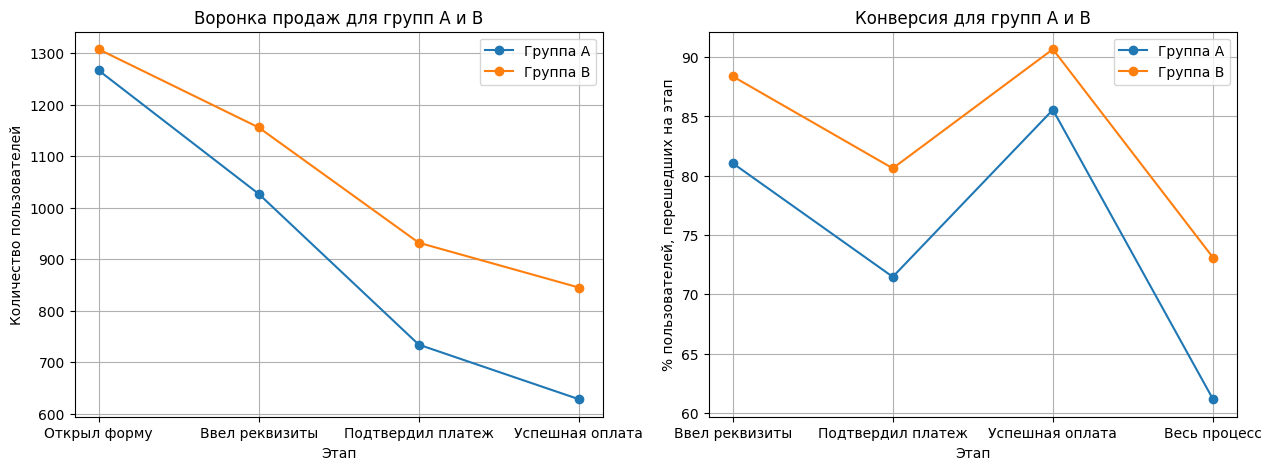

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(results.columns, funnelA, label='Группа A', marker='o')
ax1.plot(results.columns, funnelB, label='Группа B', marker='o')
ax1.grid(visible=True)
ax1.legend()
ax1.set_ylabel('Количество пользователей')
ax1.set_xlabel('Этап')
ax1.set_title('Воронка продаж для групп A и B')

ax2.plot(conversions.columns, conversions.loc['A'], label='Группа A', marker='o')
ax2.plot(conversions.columns, conversions.loc['B'], label='Группа B', marker='o')
ax2.grid(visible=True)
ax2.legend()
ax2.set_ylabel('% пользователей, перешедших на этап')
ax2.set_xlabel('Этап')
ax2.set_title('Конверсия для групп A и B')

plt.show()

### 3. Анализ и рекомендации

Наша метрика - конверсия за весь процесс:
  - Для группы A: **61.2**%
  - Для группы B: **73.1**%


Проверим, статистически значим ли этот результат.

Нулевой гипотезой считаем отсутствие разницы в конверсиях групп A и B.

Так как у нас 2 независимые группы и метрика - доля, используем **z-тест**.

In [54]:
from scipy import stats
from numpy import sqrt

In [62]:
n1 = dfA.shape[0]
n2 = dfB.shape[0]

p1 = conversions.loc['A', 'Весь процесс'] / 100
p2 = conversions.loc['B', 'Весь процесс'] / 100

p = (p1 * n1 + p2 * n2) / (n1 + n2)
se = sqrt(p * (1 - p) * (1 / n1 + 1 / n2))
z_value = (p2 - p1) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z_value)))
print(f'z-статистика: {z_value:.2f}')

if p_value < 0.05:
  print(f'p-value = {p_value:.3f} < alpha (0.05) => тест стат. значим')
else:
  print(f'p-value = {p_value:.3f} >= alpha (0.05) => тест НЕ стат. значим')

z-статистика: 6.46
p-value = 0.000 < alpha (0.05) => тест стат. значим


Отличия оказались неслучайными.

При этом конверсия тестовой группы **больше** конверсии контрольной группы на ~12% (значительная разница).

**Рекомендация**: rollout - запустить новую форму оплаты.